In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline


In [2]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(0)

In [6]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df['ocean_proximity'].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
import math
def plot_histogram(df, title_prefix = ''):
    num_cols = df.select_dtypes(include=np.number).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)
    plt.figure(figsize=(15, n_rows * 4))
    for i, col in enumerate(num_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.histplot(df[col], kde=True,bins=30)
        plt.title(f'{title_prefix} {col}')
    plt.tight_layout()
    plt.show()
    

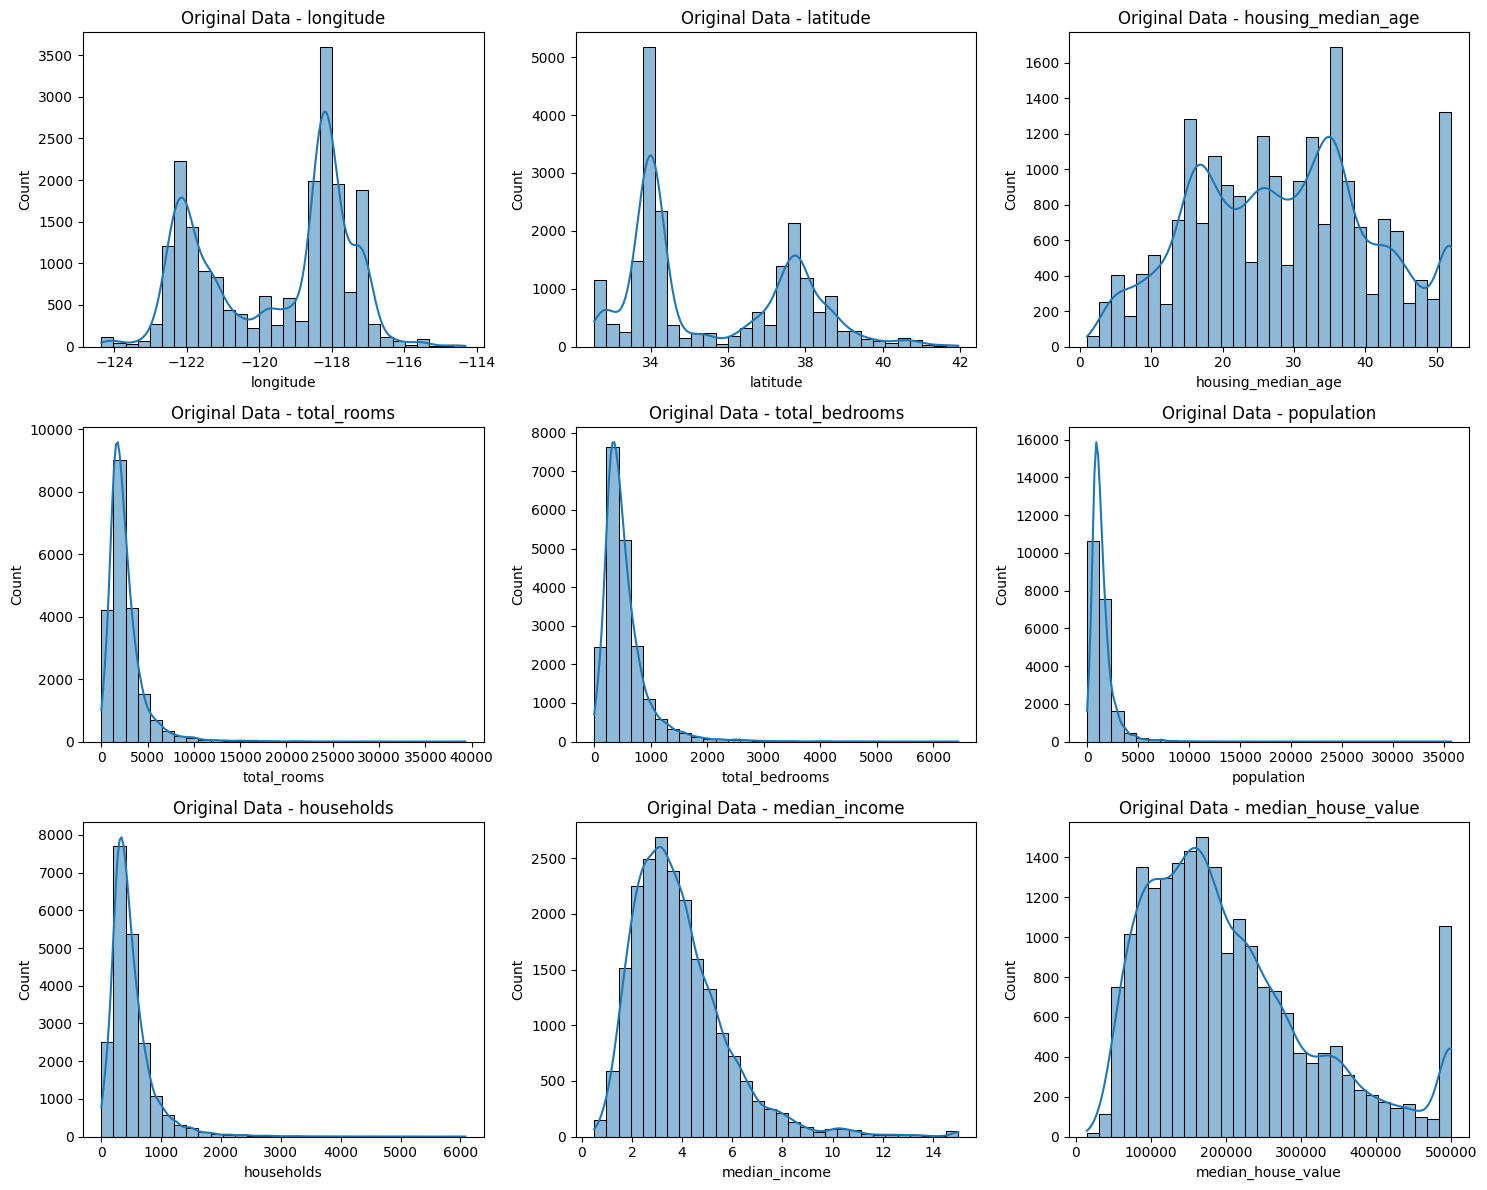

In [9]:
plot_histogram(df, title_prefix='Original Data -')

In [10]:
def find_outliers_iqr(data,threshold=1.5):
    outliers_sum = {}
    numeric_columns = data.select_dtypes(include=[np.number]).columns
    for column in numeric_columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        outliers_sum[column] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': len(outliers),
        'outliers_percentage': len(outliers) / len(data) * 100
    }
    return pd.DataFrame(outliers_sum)

In [11]:
find_outliers_iqr(df)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000
outliers_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outliers_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953


In [12]:
def remove_outliers_from_col(data,column,threshold=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

In [13]:
print('Original Data Shape:', df.shape)
df_target_clean = remove_outliers_from_col(df, 'median_house_value')
print('Target Cleaned Data Shape:', df_target_clean.shape)

Original Data Shape: (20640, 10)
Target Cleaned Data Shape: (19569, 10)


In [14]:
df_target_clean.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [15]:
df_target_clean['total_bedrooms'] = df_target_clean['total_bedrooms'].fillna(df_target_clean['total_bedrooms'].median())
df_target_clean.isnull().sum()

/var/folders/dq/drcnmlqj2rd80tmyxn9jk3x00000gn/T/ipykernel_40267/2646866393.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target_clean['total_bedrooms'] = df_target_clean['total_bedrooms'].fillna(df_target_clean['total_bedrooms'].median())


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [16]:
df_target_clean['ocean_proximity'].value_counts() # onehotencoding


ocean_proximity
<1H OCEAN     8552
INLAND        6519
NEAR OCEAN    2419
NEAR BAY      2074
ISLAND           5
Name: count, dtype: int64

In [17]:
df_target_clean = pd.get_dummies(df_target_clean,columns=['ocean_proximity'],drop_first=True)
df_target_clean.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


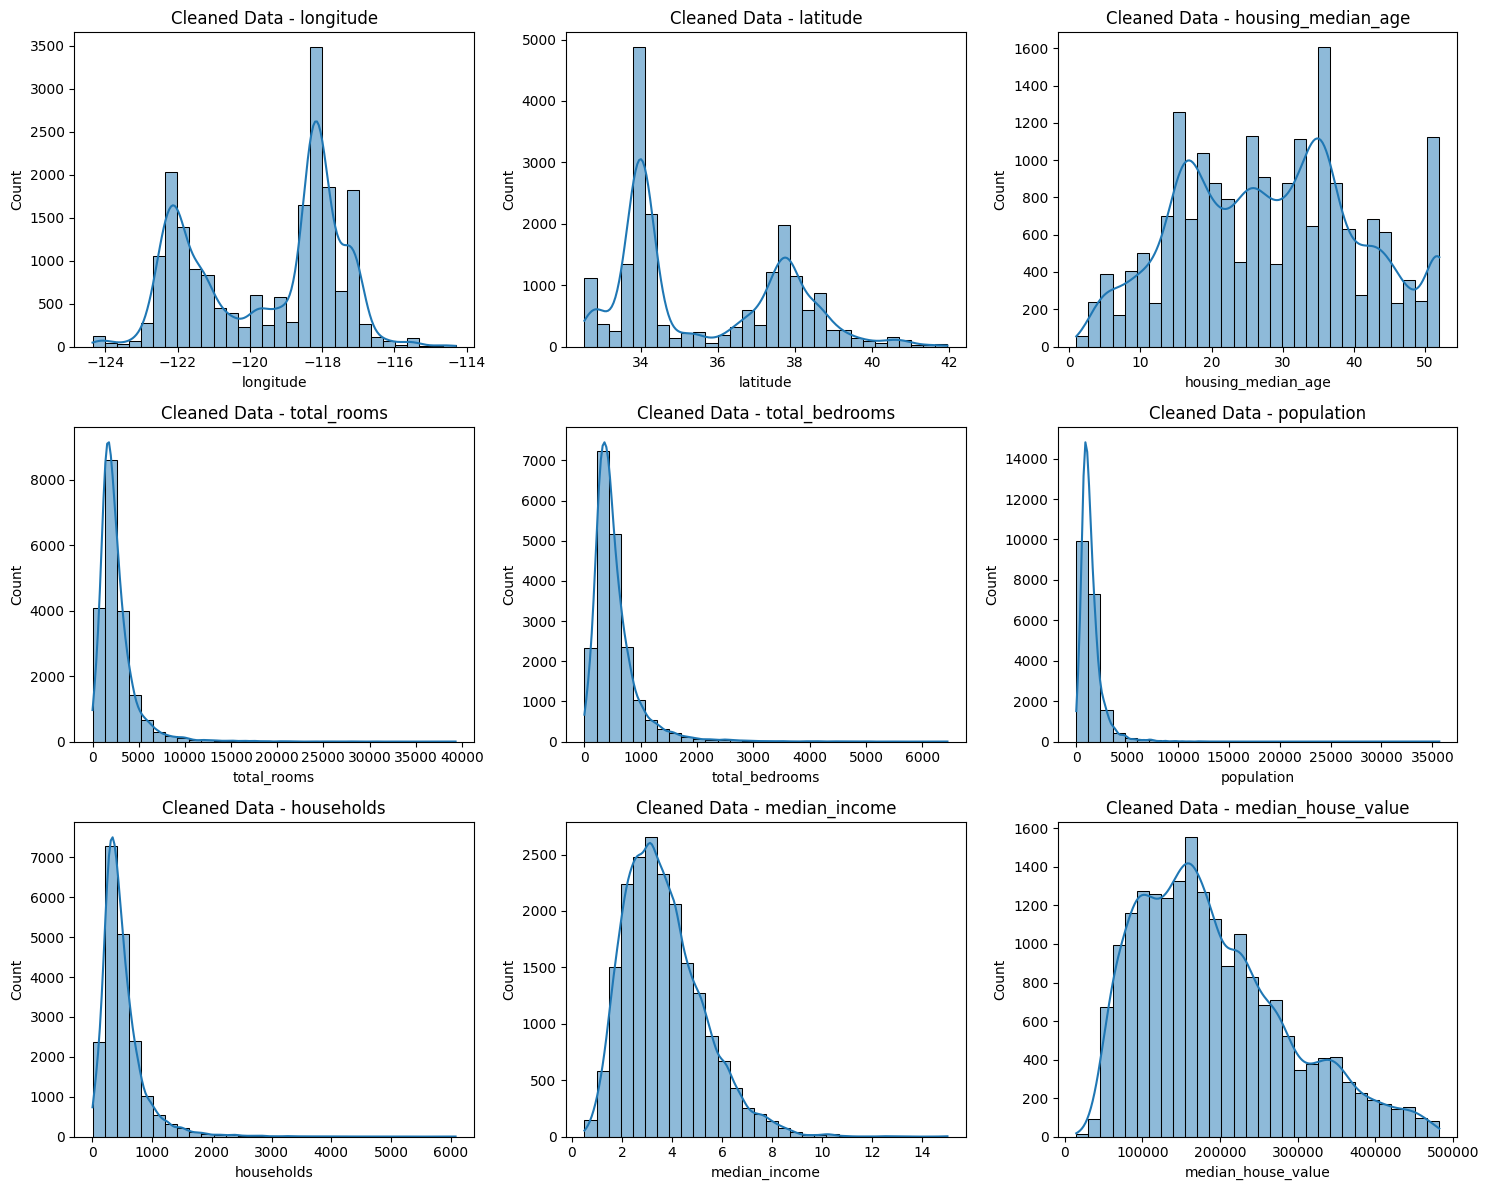

In [18]:
plot_histogram(df_target_clean, title_prefix='Cleaned Data -')

In [19]:
from sklearn.model_selection import train_test_split
X = df_target_clean.drop('median_house_value', axis=1)
y = df_target_clean['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from scipy import stats


In [21]:
y_train_transformed , lambda_y = stats.boxcox(y_train)


In [22]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.exp(np.log(lambda_ * y + 1) / lambda_)
# convert back to original scale

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [25]:
def evaluate_model(true,predicted):
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    mae = mean_absolute_error(true, predicted)
    adjr2 = 1 - (1 - r2) * (len(true) - 1) / (len(true) - X_test.shape[1] - 1)
    return mse, r2, mae,adjr2

In [27]:
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LinearRegression': LinearRegression(),
    'SVR': SVR(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42)
}

In [28]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train_transformed)
    y_pred_transformed = model.predict(X_test_scaled)
    y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)
    mse, r2, mae, adjr2 = evaluate_model(y_test, y_pred_original)
    print(f"{list(models.keys())[i]} - MSE: {mse:.2f}, R2: {r2:.4f}, MAE: {mae:.2f}, Adjusted R2: {adjr2:.4f}")
    print('-------------------------')

Random Forest - MSE: 1845856918.70, R2: 0.8004, MAE: 28408.19, Adjusted R2: 0.7998
-------------------------
AdaBoost - MSE: 4250185736.11, R2: 0.5404, MAE: 49812.20, Adjusted R2: 0.5390
-------------------------
Gradient Boosting - MSE: 2507976731.53, R2: 0.7288, MAE: 34759.97, Adjusted R2: 0.7280
-------------------------
XGBoost - MSE: 1785028301.92, R2: 0.8070, MAE: 27919.80, Adjusted R2: 0.8064
-------------------------
LinearRegression - MSE: 3375501191.63, R2: 0.6350, MAE: 41738.27, Adjusted R2: 0.6339
-------------------------


/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ege/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


SVR - MSE: 2727939006.10, R2: 0.7050, MAE: 36502.48, Adjusted R2: 0.7041
-------------------------
DecisionTreeRegressor - MSE: 3679694529.79, R2: 0.6021, MAE: 39941.39, Adjusted R2: 0.6009
-------------------------


In [29]:
from sklearn.model_selection import GridSearchCV
params_forest = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

params_xgb = {
    'n_estimators': [100, 200,300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6,0.8, 1.0]
}

grid_forest = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=params_forest, cv=5, n_jobs=-1, verbose=2)
grid_xgb = GridSearchCV(estimator=XGBRegressor(random_state=42), param_grid=params_xgb, cv=5, n_jobs=-1, verbose=2)

In [30]:
grid_forest.fit(X_train_scaled, y_train_transformed)
grid_xgb.fit(X_train_scaled, y_train_transformed)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   6.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   6.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   6.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.5s
[CV] END ma

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 6, 10],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.8, 1.0]},
             verbose=2)

In [31]:
print("Best Hyperparameters for Random Forest:", grid_forest.best_params_)
print("Best Hyperparameters for XGBoost:", grid_xgb.best_params_)
y_pred_forest_transformed = grid_forest.predict(X_test_scaled)
y_pred_xgb_transformed = grid_xgb.predict(X_test_scaled)
y_pred_forest_original = inverse_boxcox(y_pred_forest_transformed, lambda_y)
y_pred_xgb_original = inverse_boxcox(y_pred_xgb_transformed, lambda_y)
mse_forest, r2_forest, mae_forest, adjr2_forest = evaluate_model(y_test, y_pred_forest_original)
mse_xgb, r2_xgb, mae_xgb, adjr2_xgb = evaluate_model(y_test, y_pred_xgb_original)

print(f"Random Forest - MSE: {mse_forest:.2f}, R2: {r2_forest:.4f}, MAE: {mae_forest:.2f}, Adjusted R2: {adjr2_forest:.4f}")
print(f"XGBoost - MSE: {mse_xgb:.2f}, R2: {r2_xgb:.4f}, MAE: {mae_xgb:.2f}, Adjusted R2: {adjr2_xgb:.4f}")

Best Hyperparameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Random Forest - MSE: 1820303889.79, R2: 0.8032, MAE: 28261.46, Adjusted R2: 0.8026
XGBoost - MSE: 1727272814.67, R2: 0.8132, MAE: 27304.58, Adjusted R2: 0.8127
